# Binary Options Pricing

This notebook accompanies the README and implements every pricing formula in the article with worked examples and inline charts.

**Running parameters throughout:** 24-hour BTC binary call, strike $K = \$50{,}000 = $ spot, risk-free rate $r = 5\%$, volatility $\sigma = 80\%$. The volatility is a stylized parameter; readers can override it in the constants block below to reflect a different regime (BTC realized 24h vol has ranged roughly 50% to 110% over recent cycles).

The notebook covers:
1. Vanilla Black-Scholes call pricing and Greeks (reference point)
2. Binary call pricing and Greeks
3. Why the binary differs from the vanilla, in payoff and in delta
4. The trapezoidal-fuzzy-spot extension and its $\alpha$-cut interval price

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import plotly.graph_objects as go
import plotly.io as pio

# Render plotly as static PNG so figures appear inline on GitHub.
pio.renderers.default = "png"
np.random.seed(42)

# Running parameters. Override sigma for a different regime.
S0    = 50_000.0
K     = 50_000.0
r     = 0.05
sigma = 0.80
T     = 1/365  # 24 hours

## 1. Vanilla Black-Scholes for contrast

Before binary options, the vanilla European call is the right reference point. Its price, delta and gamma are smooth functions of spot. The binary version will look very different.

$$ C_{\text{vanilla}} = S_0 \, N(d_1) - K e^{-rT} N(d_2) $$

$$ d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T} $$

In [2]:
def d1(S, K, r, sigma, T):
    T_eff = np.maximum(T, 1e-10)  # guard against T -> 0 in plots
    return (np.log(S / K) + (r + sigma**2 / 2) * T_eff) / (sigma * np.sqrt(T_eff))

def d2(S, K, r, sigma, T):
    return d1(S, K, r, sigma, T) - sigma * np.sqrt(np.maximum(T, 1e-10))

def vanilla_call_price(S, K, r, sigma, T):
    return S * norm.cdf(d1(S, K, r, sigma, T)) - K * np.exp(-r * T) * norm.cdf(d2(S, K, r, sigma, T))

def vanilla_call_delta(S, K, r, sigma, T):
    return norm.cdf(d1(S, K, r, sigma, T))

def vanilla_gamma(S, K, r, sigma, T):
    return norm.pdf(d1(S, K, r, sigma, T)) / (S * sigma * np.sqrt(np.maximum(T, 1e-10)))

def vanilla_vega(S, K, r, sigma, T):
    return S * norm.pdf(d1(S, K, r, sigma, T)) * np.sqrt(np.maximum(T, 1e-10))

## 2. Binary call pricing

A binary (cash-or-nothing) call pays $\$1$ if $S_T \ge K$, else $0$. Its present value is the **discounted risk-neutral probability of finishing in-the-money**:

$$ C_{\text{binary}} = e^{-rT} N(d_2) $$

Note: this uses $d_2$, not $d_1$. The payoff depends only on whether $S_T > K$, not on how far above.

The Greeks follow by differentiation. Binary delta and gamma are *not* monotone in spot; they peak near the strike, and the gamma flips sign across the strike.

In [3]:
def binary_call_price(S, K, r, sigma, T):
    return np.exp(-r * T) * norm.cdf(d2(S, K, r, sigma, T))

def binary_call_delta(S, K, r, sigma, T):
    return np.exp(-r * T) * norm.pdf(d2(S, K, r, sigma, T)) / (S * sigma * np.sqrt(np.maximum(T, 1e-10)))

def binary_call_gamma(S, K, r, sigma, T):
    _d1 = d1(S, K, r, sigma, T)
    _d2 = d2(S, K, r, sigma, T)
    return -np.exp(-r * T) * norm.pdf(_d2) * _d1 / (S**2 * sigma**2 * np.maximum(T, 1e-10))

def binary_call_vega(S, K, r, sigma, T):
    _d1 = d1(S, K, r, sigma, T)
    _d2 = d2(S, K, r, sigma, T)
    return -np.exp(-r * T) * norm.pdf(_d2) * _d1 / sigma

## 3. Worked example: 24h BTC binary call

The values printed below are quoted verbatim in the article. The position math interprets `delta` as $dC/dS$ (dimensionless): a position of $N$ contracts has dollar P\&L $= N \cdot \delta \cdot dS$ for a small spot move $dS$. The hedge in BTC is $N \cdot \delta$ units of spot.

In [4]:
print(f"d1                        = {d1(S0,K,r,sigma,T):+.4f}")
print(f"d2                        = {d2(S0,K,r,sigma,T):+.4f}")
print(f"binary call price         = ${binary_call_price(S0,K,r,sigma,T):.4f}")
print(f"binary delta (per $1 spot)= {binary_call_delta(S0,K,r,sigma,T):.3e}")
print(f"binary gamma              = {binary_call_gamma(S0,K,r,sigma,T):.3e}")
print(f"binary vega (per unit s)  = {binary_call_vega(S0,K,r,sigma,T):.3e}")
print()
print("--- Position math for 10,000 contracts ---")
n = 10_000
total_delta = n * binary_call_delta(S0,K,r,sigma,T)
print(f"premium received          = ${n * binary_call_price(S0,K,r,sigma,T):,.2f}")
print(f"position delta (dC/dS)    = {total_delta:+.4f}  (dimensionless)")
print(f"BTC-equivalent hedge      = {total_delta:.4f} BTC long spot")
print(f"capital deployed for hedge= ${total_delta * S0:,.2f}")

d1                        = +0.0242
d2                        = -0.0177
binary call price         = $0.4929
binary delta (per $1 spot)= 1.905e-04
binary gamma              = -2.203e-09
binary vega (per unit s)  = -1.207e-02

--- Position math for 10,000 contracts ---
premium received          = $4,928.85
position delta (dC/dS)    = +1.9049  (dimensionless)
BTC-equivalent hedge      = 1.9049 BTC long spot
capital deployed for hedge= $95,244.36


## 4. Why binary differs from vanilla: payoff diagrams

The vanilla call's payoff at expiry is a continuous hockey stick. The binary call's is a step function. That single fact drives every hedging difficulty in the [companion hedging notebook](https://github.com/rolandgem/binary-options-hedging).

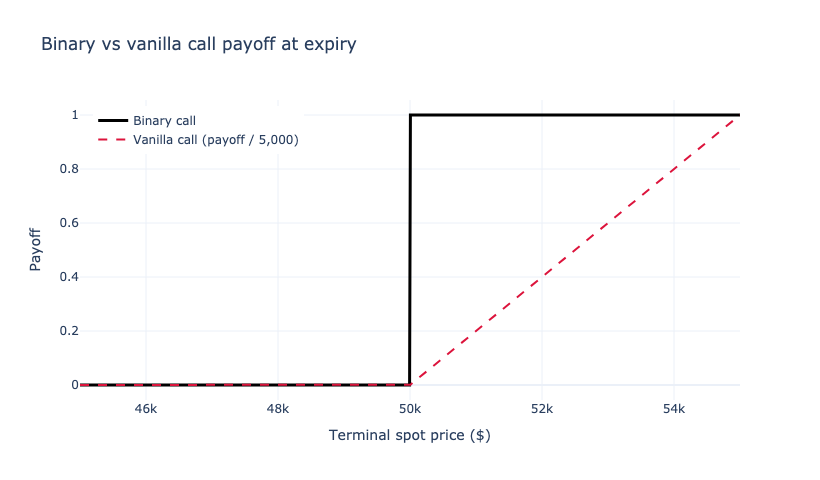

In [5]:
S_grid = np.linspace(45_000, 55_000, 800)
binary_pay = (S_grid >= K).astype(float)
vanilla_pay = np.maximum(S_grid - K, 0) / 5000  # divided by 5,000 to plot on the same axis

fig = go.Figure()
fig.add_trace(go.Scatter(x=S_grid, y=binary_pay, name="Binary call",
                         line=dict(color="black", width=3)))
fig.add_trace(go.Scatter(x=S_grid, y=vanilla_pay, name="Vanilla call (payoff / 5,000)",
                         line=dict(color="crimson", width=2, dash="dash")))
fig.update_layout(
    title="Binary vs vanilla call payoff at expiry",
    xaxis_title="Terminal spot price ($)", yaxis_title="Payoff",
    template="plotly_white", width=820, height=480,
    legend=dict(x=0.02, y=0.98, title_text=""))
fig.show()

## 5. Binary delta: concentrating into a spike

For a vanilla call, delta is monotone in spot, ranging smoothly from 0 to 1. For a binary call, delta peaks **at the strike** and falls off either side. As expiry approaches, that peak gets sharper. With one hour left, a tiny move across the strike can flip the entire $\$1$ payoff.

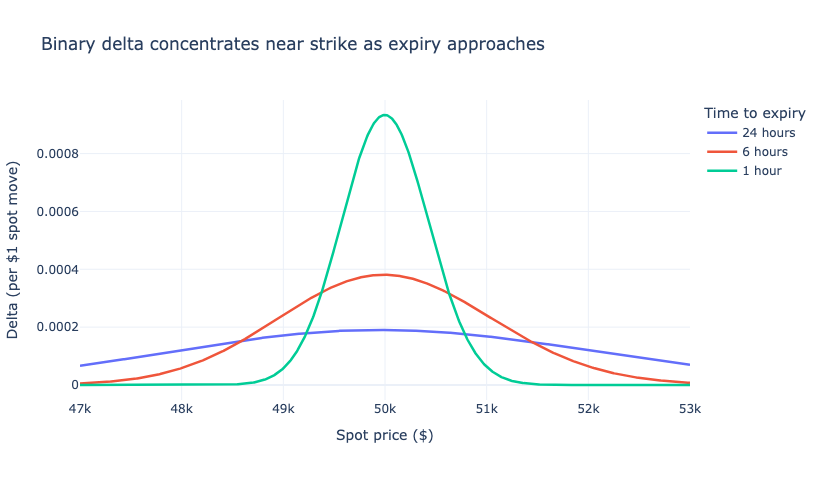

In [6]:
S_grid = np.linspace(47_000, 53_000, 800)
horizons = [(24, "24 hours"), (6, "6 hours"), (1, "1 hour")]

fig = go.Figure()
for hrs, label in horizons:
    T_h = hrs / 24 / 365
    delta = binary_call_delta(S_grid, K, r, sigma, T_h)
    fig.add_trace(go.Scatter(x=S_grid, y=delta, name=label, line=dict(width=2.5)))

fig.update_layout(
    title="Binary delta concentrates near strike as expiry approaches",
    xaxis_title="Spot price ($)", yaxis_title="Delta (per $1 spot move)",
    template="plotly_white", width=820, height=480,
    legend=dict(title_text="Time to expiry"))
fig.show()

## 6. Binary gamma: flipping sign across the strike

Vanilla gamma is everywhere positive (long convexity). Binary gamma is positive *below* the strike and negative *above*: as spot rises through the strike, delta first surges and then collapses. This is what makes binary positions so unstable to delta-hedge near expiry.

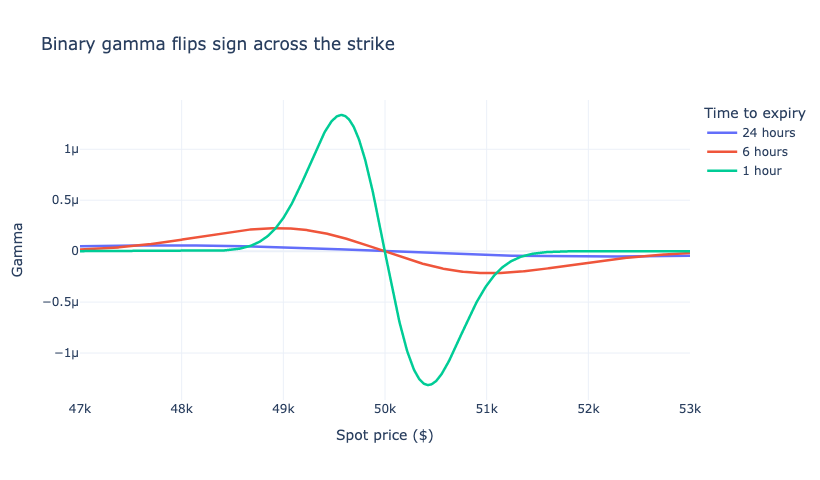

In [7]:
fig = go.Figure()
for hrs, label in horizons:
    T_h = hrs / 24 / 365
    g = binary_call_gamma(S_grid, K, r, sigma, T_h)
    fig.add_trace(go.Scatter(x=S_grid, y=g, name=label, line=dict(width=2.5)))

fig.update_layout(
    title="Binary gamma flips sign across the strike",
    xaxis_title="Spot price ($)", yaxis_title="Gamma",
    template="plotly_white", width=820, height=480,
    legend=dict(title_text="Time to expiry"))
fig.show()

## 7. Fuzzy-spot extension: $\alpha$-cut interval pricing

Standard pricing assumes a single observable spot $S_0$. In practice, the spot mid-price is ambiguous: bid-ask, last-trade lag, and cross-venue divergence all create epistemic uncertainty over $S_0$ that volatility alone does not capture. Fuzzy set theory provides a framework to encode this as a graded *plausibility* on the spot, and to derive a corresponding price interval rather than a point. References: Yoshida (2003), Wu (2004), Thavaneswaran et al. (2009), Buckley and Eslami (2008).

We model $\tilde{S}_0$ as a **trapezoidal fuzzy number** with core $[S_a, S_b]$ (full plausibility, $\mu = 1$), support $[S_a - \gamma, S_b + \beta]$, and linear edges. The $\alpha$-cut at level $\alpha \in [0, 1]$ is

$$ A(\alpha) = \{s : \mu(s) \geq \alpha\} = [\,S_a - \gamma(1-\alpha),\, S_b + \beta(1-\alpha)\,]. $$

Since the crisp Black-Scholes binary price is monotone increasing in $S_0$, the $\alpha$-cut binary price is the closed interval

$$ C(\alpha) = \big[\, e^{-rT} N(d_2(a(\alpha))),\ e^{-rT} N(d_2(b(\alpha))) \,\big]. $$

The interval is widest at $\alpha = 0$ (full support) and tightest at $\alpha = 1$ (core only). For directional fuzzy views (core not centered on the crisp spot), the interval is asymmetric around the crisp price.

In [8]:
def alpha_cut_endpoints(S_a, S_b, gamma_l, beta_r, alpha):
    """Return [a(alpha), b(alpha)] for a trapezoidal fuzzy number."""
    a = S_a - gamma_l * (1 - alpha)
    b = S_b + beta_r * (1 - alpha)
    return a, b

def trapezoidal_membership(s, S_a, S_b, gamma_l, beta_r):
    s = np.asarray(s, dtype=float)
    mu = np.zeros_like(s)
    in_core = (s >= S_a) & (s <= S_b)
    in_left = (s >= S_a - gamma_l) & (s < S_a)
    in_right = (s > S_b) & (s <= S_b + beta_r)
    mu = np.where(in_core, 1.0, mu)
    mu = np.where(in_left, (s - (S_a - gamma_l)) / gamma_l, mu)
    mu = np.where(in_right, ((S_b + beta_r) - s) / beta_r, mu)
    return mu

### Three trapezoidal specifications

We compare three views: a symmetric core centred on the crisp spot, a bullish core shifted up by $\$1{,}000$, and a bearish core shifted down. Each has core width $\$1{,}000$ and support extension $\$1{,}000$ on each side.

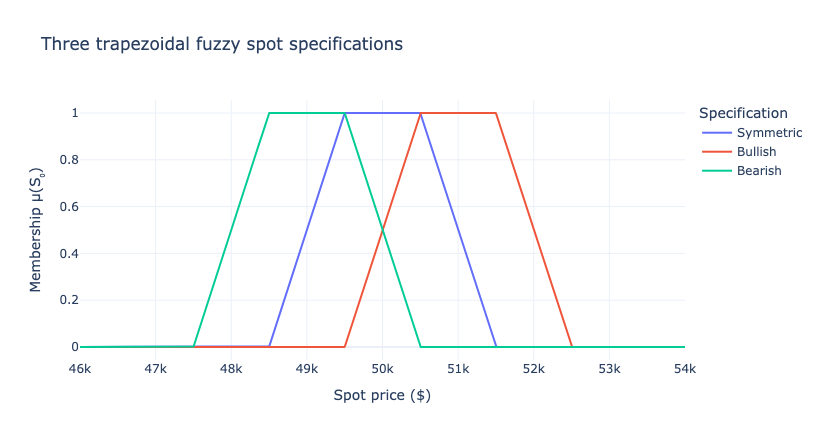

In [9]:
specs = [
    ("Symmetric",  49_500, 50_500, 1_000, 1_000),
    ("Bullish",    50_500, 51_500, 1_000, 1_000),
    ("Bearish",    48_500, 49_500, 1_000, 1_000),
]

S_grid = np.linspace(46_000, 54_000, 800)
fig = go.Figure()
for name, Sa, Sb, gl, br in specs:
    mu = trapezoidal_membership(S_grid, Sa, Sb, gl, br)
    fig.add_trace(go.Scatter(x=S_grid, y=mu, name=name, line=dict(width=2)))
fig.update_layout(
    title="Three trapezoidal fuzzy spot specifications",
    xaxis_title="Spot price ($)", yaxis_title="Membership μ(S₀)",
    template="plotly_white", width=820, height=440,
    legend=dict(title_text="Specification"))
fig.show()

### $\alpha$-cut binary call prices

For each specification, the $\alpha$-cut binary price is computed as the BS binary price evaluated at the two endpoints of the $\alpha$-cut. The crisp price (at $S_0 = \$50{,}000$) is the same row-to-row by construction; the $\alpha$-cut interval shifts and widens differently across specifications.

In [10]:
rows = []
crisp = binary_call_price(S0, K, r, sigma, T)
for name, Sa, Sb, gl, br in specs:
    row = {"Specification": name, "Crisp": round(crisp, 4)}
    for alpha in [1.0, 0.5, 0.0]:
        a, b = alpha_cut_endpoints(Sa, Sb, gl, br, alpha)
        cl = binary_call_price(a, K, r, sigma, T)
        ch = binary_call_price(b, K, r, sigma, T)
        row[f"C(α={alpha:.1f})"] = f"[{cl:.3f}, {ch:.3f}]"
    rows.append(row)

df_alpha = pd.DataFrame(rows)
df_alpha[["Specification", "C(α=1.0)", "C(α=0.5)", "C(α=0.0)", "Crisp"]]

,Specification,C(α=1.0),C(α=0.5),C(α=0.0),Crisp
0,Symmetric,"[0.398, 0.587]","[0.308, 0.675]","[0.228, 0.754]",0.4929
1,Bullish,"[0.587, 0.754]","[0.493, 0.821]","[0.398, 0.874]",0.4929
2,Bearish,"[0.228, 0.398]","[0.160, 0.493]","[0.107, 0.587]",0.4929


### Plotting the full $\alpha$-cut envelope

Sweeping $\alpha$ from 0 to 1 traces out the full interval price as a function of plausibility level. The lower and upper bounds bracket the crisp price (when the trapezoidal is centred on it) or sit asymmetrically around it (for directional views).

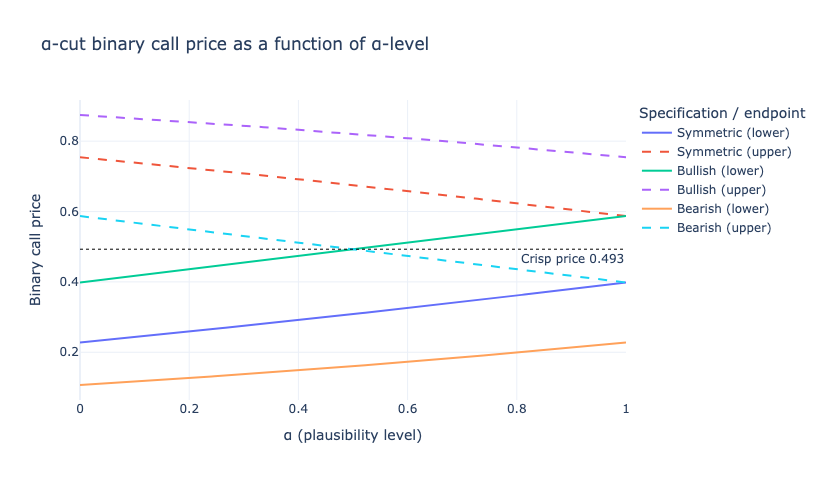

In [11]:
alpha_grid = np.linspace(0, 1, 200)

fig = go.Figure()
for name, Sa, Sb, gl, br in specs:
    lows, highs = [], []
    for alpha in alpha_grid:
        a, b = alpha_cut_endpoints(Sa, Sb, gl, br, alpha)
        lows.append(binary_call_price(a, K, r, sigma, T))
        highs.append(binary_call_price(b, K, r, sigma, T))
    fig.add_trace(go.Scatter(x=alpha_grid, y=lows, name=f"{name} (lower)",
                             line=dict(width=2)))
    fig.add_trace(go.Scatter(x=alpha_grid, y=highs, name=f"{name} (upper)",
                             line=dict(width=2, dash="dash")))

fig.add_hline(y=crisp, line=dict(color="black", width=1, dash="dot"),
              annotation_text="Crisp price 0.493", annotation_position="bottom right")
fig.update_layout(
    title="α-cut binary call price as a function of α-level",
    xaxis_title="α (plausibility level)", yaxis_title="Binary call price",
    template="plotly_white", width=820, height=480,
    legend=dict(title_text="Specification / endpoint"))
fig.show()

### Use case: market-maker quote width from epistemic uncertainty

A trader skeptical of the BS distribution can quote bid = lower $\alpha$-cut, ask = upper $\alpha$-cut, with the width directly reflecting their epistemic uncertainty about $S_0$. The width composes naturally with the hedging-cost and inventory-skew terms developed in the hedging article: total quoted spread $=$ epistemic spread (from $\alpha$-cut) $+$ hedging cost $+$ residual risk premium $+$ profit margin.

The trapezoidal width parameters $\gamma, \beta$ should be calibrated externally rather than fitted: cross-venue spot dispersion, mid-bid spread on the underlying, realized-vs-implied vol gap, or strike-by-strike disagreement in prediction markets are all sensible inputs.

**Caveats:**
- The fuzzy price is **not** a no-arbitrage price. The membership function is epistemic, not a Radon-Nikodym derivative. The construction belongs to the broader family of interval-valued and coherent risk pricing approaches.
- Fuzzifying volatility ($\tilde{\sigma}$) instead of spot is a valid alternative, but the binary price is not monotone in $\sigma$ across all strike-spot configurations, so $\alpha$-cut endpoints require interior optimization.

---

**Next:** [`binary-options-hedging`](https://github.com/rolandgem/binary-options-hedging) implements delta hedging, bull-spread replication, and dynamic multi-Greek portfolios on top of the pricing functions above, with Monte-Carlo P\&L distributions and a market-maker spread-capture model.